Shape of X: (208, 20)
Number of features: 20
Feature columns:
max_metal_ligand_bond_length
SGR No.
mean_metal_ligand_bond_length
vol_per_atom
avg_Martynov-Batsanov EN
polyhedron volume
avg_Thermal conductivity (W/m•K)
avg_Number of outer shell electrons
std_Heat of fusion (kJ/mol)
1/R2
avg_Number of d electrons
std_Number of outer shell electrons
avg_Mulliken EN
avg_First ionization energy (kJ/mol)
c
std_Number of valence electrons
max_Heat atomization (kJ/mol)
std_Atomic weight
distortion_index
std_Thermal conductivity (W/m•K)


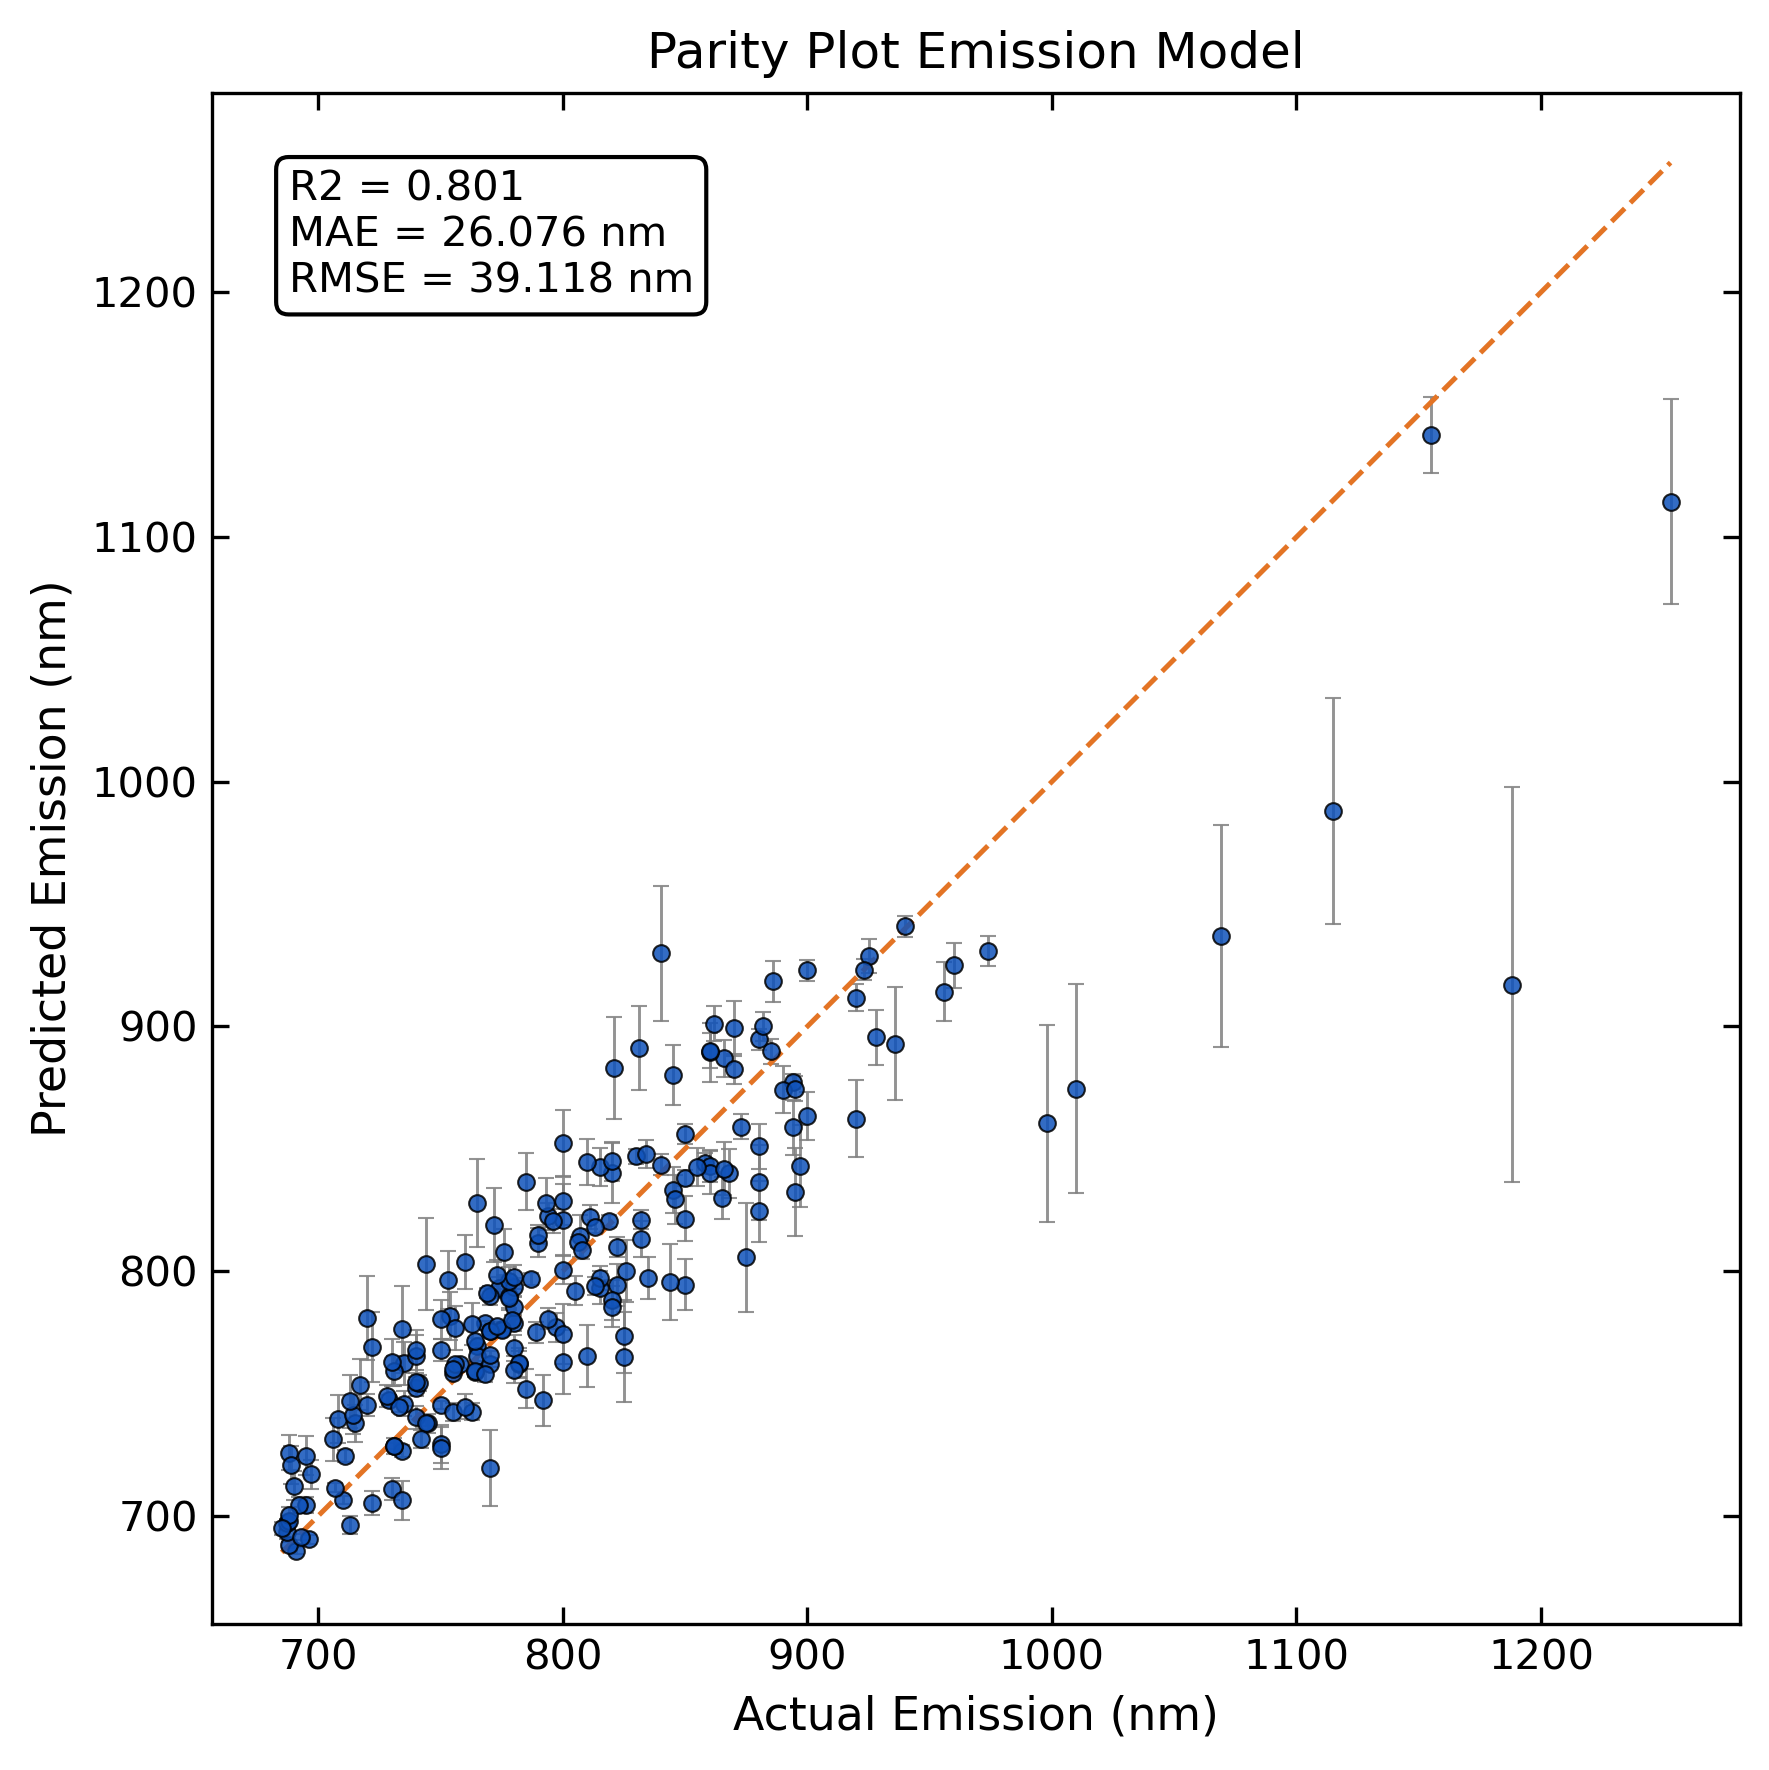


10-fold CV performance
R2   = 0.8007
MAE  = 26.0763 nm
RMSE = 39.1182 nm

Predictions saved to: c:\Users\akumar54\Desktop\PHD\new cr3+ model\model_revision\em_model\predicted_em.xlsx


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from catboost import CatBoostRegressor
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error


# Keep this notebook, training Excel, and prediction Excel in the same folder
base_dir = Path.cwd()
train_file = base_dir / "trainingset_em.xlsx"
predict_file = base_dir / "To_predict_em.xlsx"
output_file = base_dir / "predicted_em.xlsx"

EV_NM = 1239.8419843320026
PLOT_RS = 5
UNCERTAINTY_RS = list(range(5, 55, 5))
N_SPLITS = 10

params = {
    "iterations": 2092,
    "learning_rate": 0.024495702352497536,
    "depth": 4,
    "l2_leaf_reg": 2,
    "random_strength": 2.5013784369774434,
    "subsample": 0.8923775826709153,
    "loss_function": "RMSE",
    "eval_metric": "RMSE",
    "random_seed": 42,
    "verbose": False,
}


def make_model():
    return CatBoostRegressor(**params)


def load_xy(path):
    df = pd.read_excel(path)
    df.columns = df.columns.astype(str).str.strip()

    target_nm_col = df.columns[1]
    feature_cols = list(df.columns[3:])

    df[target_nm_col] = pd.to_numeric(df[target_nm_col], errors="coerce")
    if df[target_nm_col].isna().any() or (df[target_nm_col] <= 0).any():
        raise ValueError("Target wavelength column contains invalid values.")

    y_ev = EV_NM / df[target_nm_col]
    X = df[feature_cols].apply(pd.to_numeric, errors="coerce")

    if X.isna().any().any():
        bad_cols = X.columns[X.isna().any()].tolist()
        raise ValueError(f"Feature columns contain invalid values: {bad_cols}")

    return df, X, y_ev, df[target_nm_col].values, feature_cols


def predict_nm(model, scaler, X_data):
    pred_ev = model.predict(scaler.transform(X_data))
    return EV_NM / pred_ev


df, X, y, actual_nm, feature_cols = load_xy(train_file)

print("Shape of X:", X.shape)
print("Number of features:", X.shape[1])
print("Feature columns:")
for col in feature_cols:
    print(col)


# Main CV prediction for parity plot
plot_pred_nm = np.zeros(len(df))
kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=PLOT_RS)

for train_idx, val_idx in kf.split(X):
    scaler = StandardScaler()
    X_train = X.iloc[train_idx]
    X_val = X.iloc[val_idx]

    X_train_scaled = scaler.fit_transform(X_train)

    model = make_model()
    model.fit(
        X_train_scaled,
        y.iloc[train_idx],
        eval_set=(scaler.transform(X_val), y.iloc[val_idx]),
        use_best_model=True,
        early_stopping_rounds=100,
    )

    plot_pred_nm[val_idx] = predict_nm(model, scaler, X_val)

r2 = r2_score(actual_nm, plot_pred_nm)
mae = mean_absolute_error(actual_nm, plot_pred_nm)
rmse = np.sqrt(mean_squared_error(actual_nm, plot_pred_nm))


# Prediction file
predict_df = pd.read_excel(predict_file)
predict_df.columns = predict_df.columns.astype(str).str.strip()

X_new = predict_df.iloc[:, 2:].apply(pd.to_numeric, errors="coerce")
if X_new.shape[1] != X.shape[1]:
    raise ValueError("Prediction file feature count does not match training file.")

X_new.columns = feature_cols
if X_new.isna().any().any():
    bad_cols = X_new.columns[X_new.isna().any()].tolist()
    raise ValueError(f"Prediction feature columns contain invalid values: {bad_cols}")


# 100-model uncertainty
train_uncertainty_preds = []
new_uncertainty_preds = []

for rs in UNCERTAINTY_RS:
    kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=rs)

    for train_idx, _ in kf.split(X):
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X.iloc[train_idx])

        model = make_model()
        model.fit(X_train_scaled, y.iloc[train_idx])

        train_uncertainty_preds.append(predict_nm(model, scaler, X))
        new_uncertainty_preds.append(predict_nm(model, scaler, X_new))

train_uncertainty_nm = np.std(np.array(train_uncertainty_preds), axis=0)
new_uncertainty_nm = np.std(np.array(new_uncertainty_preds), axis=0)


# Final prediction on all data
final_scaler = StandardScaler()
X_scaled = final_scaler.fit_transform(X)

final_model = make_model()
final_model.fit(X_scaled, y)

pred_new_nm = predict_nm(final_model, final_scaler, X_new)

result_df = predict_df.copy()
result_df["prediction"] = pred_new_nm
result_df["uncertainty_nm"] = new_uncertainty_nm

if "1/R2" in result_df.columns:
    result_df["R"] = np.sqrt(1 / pd.to_numeric(result_df["1/R2"], errors="coerce"))

save_cols = ["Formula", "prediction", "uncertainty_nm"]
if "R" in result_df.columns:
    save_cols.append("R")
if "SGR No." in result_df.columns:
    save_cols.append("SGR No.")

result_df[save_cols].to_excel(output_file, index=False)


# Parity plot
plt.figure(figsize=(6, 6), dpi=300)

plt.errorbar(
    actual_nm,
    plot_pred_nm,
    yerr=train_uncertainty_nm,
    fmt="o",
    markersize=4,
    color="#0F52BA",
    ecolor="gray",
    elinewidth=0.7,
    capsize=2,
    markeredgecolor="black",
    markeredgewidth=0.5,
    alpha=0.85,
)

min_val = min(actual_nm.min(), plot_pred_nm.min())
max_val = max(actual_nm.max(), plot_pred_nm.max())

plt.plot([min_val, max_val], [min_val, max_val], "--", color="#E37425", linewidth=1.2)

plt.xlabel("Actual Emission (nm)", fontsize=11)
plt.ylabel("Predicted Emission (nm)", fontsize=11)
plt.title("Parity Plot Emission Model", fontsize=12)

plt.text(
    0.05,
    0.95,
    f"R2 = {r2:.3f}\nMAE = {mae:.3f} nm\nRMSE = {rmse:.3f} nm",
    transform=plt.gca().transAxes,
    va="top",
    fontsize=10,
    bbox=dict(facecolor="white", edgecolor="black", boxstyle="round,pad=0.3"),
)

plt.tick_params(axis="both", which="both", direction="in", length=4, width=0.8, top=True, right=True)

for spine in plt.gca().spines.values():
    spine.set_linewidth(0.8)

plt.tight_layout()
plt.show()

print("\n10-fold CV performance")
print(f"R2   = {r2:.4f}")
print(f"MAE  = {mae:.4f} nm")
print(f"RMSE = {rmse:.4f} nm")
print(f"\nPredictions saved to: {output_file}")
